In [64]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import shap
import os
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [65]:
from google import genai

client = genai.Client(
    api_key=os.getenv("GEMINI_API_KEY")
)

print("Gemini client created successfully!")

response = client.models.generate_content(
    model="gemini-3.1-flash-lite",
    contents="Explain customer churn prediction in simple terms."
)

Gemini client created successfully!


In [66]:
df = pd.read_excel("data_cleaned.xlsx")

In [67]:
df.shape

(7032, 29)

In [68]:
df.columns.to_list()

['City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'CLTV',
 'Total Services',
 'New Customer',
 'Avg Monthly Spend']

In [69]:
location_cols = [
    'City',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude'
]

df.drop(columns=location_cols, inplace=True)

In [70]:
# Features and Target
X = df.drop(columns='Churn Label')
y = df['Churn Label']

In [71]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (7032, 23)
Target: (7032,)


In [72]:
y.value_counts()

Churn Label
No     5163
Yes    1869
Name: count, dtype: int64

In [73]:
y = y.map({
    'No': 0,
    'Yes': 1
})

In [74]:
y.value_counts()

Churn Label
0    5163
1    1869
Name: count, dtype: int64

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [76]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTraining Churn Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Churn Distribution:")
print(y_test.value_counts(normalize=True))

X_train: (5625, 23)
X_test: (1407, 23)

Training Churn Distribution:
Churn Label
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Testing Churn Distribution:
Churn Label
0    0.734186
1    0.265814
Name: proportion, dtype: float64


In [77]:
X.dtypes

Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges        float64
CLTV                   int64
Total Services         int64
New Customer           int64
Avg Monthly Spend    float64
dtype: object

In [78]:
numeric = ['int64', 'float64']
numeric_features = X.select_dtypes(include = numeric).columns

categorical_features = X.select_dtypes(include=str).columns


print(categorical_features)

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='str')


In [79]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [80]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [81]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(5625, 50)
(1407, 50)


# MODEL TRAINING

In [82]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [83]:
log_model.fit(X_train_processed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [84]:
y_pred = log_model.predict(X_test_processed)
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1407,))

In [85]:
y_prob = log_model.predict_proba(X_test_processed)[:, 1]
y_prob

array([0.03487119, 0.65388919, 0.00731112, ..., 0.14416289, 0.02655058,
       0.00159607], shape=(1407,))

## 📊 Logistic Regression Results

In [86]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression Results")
print("---------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Results
---------------------
Accuracy : 0.7996
Precision: 0.6386
Recall   : 0.5668
F1 Score : 0.6006
ROC-AUC  : 0.842

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1033
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.73      0.73      1407
weighted avg       0.79      0.80      0.80      1407



*The Logistic Regression baseline achieved an accuracy of 79.96% and a ROC-AUC of 0.842, demonstrating good overall discriminatory performance. However, the recall for the churn class was 56.68%, indicating that the model missed a considerable proportion of actual churners. Therefore, additional models and optimization techniques will be evaluated to improve churn detection.*

## 📊 Decision Tree Classifier Results

In [87]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_processed, y_train)

y_pred_dt = dt_model.predict(X_test_processed)
y_prob_dt = dt_model.predict_proba(X_test_processed)[:, 1]

In [88]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", round(accuracy_dt, 4))
print("Precision:", round(precision_dt, 4))
print("Recall   :", round(recall_dt, 4))
print("F1 Score :", round(f1_dt, 4))
print("ROC-AUC  :", round(roc_auc_dt, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
---------------------
Accuracy : 0.7399
Precision: 0.5106
Recall   : 0.5134
F1 Score : 0.512
ROC-AUC  : 0.6676

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1033
           1       0.51      0.51      0.51       374

    accuracy                           0.74      1407
   macro avg       0.67      0.67      0.67      1407
weighted avg       0.74      0.74      0.74      1407



## 📊 Random Forest Results

In [89]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_test_processed)

y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

In [90]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))
print("ROC-AUC  :", round(roc_auc_rf, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
---------------------
Accuracy : 0.7868
Precision: 0.6259
Recall   : 0.492
F1 Score : 0.5509
ROC-AUC  : 0.8321

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



*Among the three evaluated models, Logistic Regression achieved the best overall performance, with an accuracy of 79.96% and ROC-AUC of 0.842. It also achieved the highest recall (56.68%) and F1-score (60.06%) for the churn class, indicating a stronger ability to identify customers at risk of churning. Decision Tree and Random Forest models showed comparatively lower performance across the evaluated metrics. Therefore, Logistic Regression was selected as the initial best-performing model.*

# FINE TUNING LOGISTIC REGRESSION MODEL

In [91]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [92]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced'],
    'solver': ['liblinear', 'lbfgs']
}

In [93]:
grid_search = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [94]:
grid_search.fit(X_train_processed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [95]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'C': 0.01, 'class_weight': 'balanced', 'solver': 'lbfgs'}


In [96]:
best_log_model = grid_search.best_estimator_

In [97]:
y_pred_tuned = best_log_model.predict(X_test_processed)

y_prob_tuned = best_log_model.predict_proba(X_test_processed)[:, 1]

In [98]:
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print("Tuned Logistic Regression Results")
print("----------------------------------")
print("Accuracy :", round(accuracy_tuned, 4))
print("Precision:", round(precision_tuned, 4))
print("Recall   :", round(recall_tuned, 4))
print("F1 Score :", round(f1_tuned, 4))
print("ROC-AUC  :", round(roc_auc_tuned, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Tuned Logistic Regression Results
----------------------------------
Accuracy : 0.7399
Precision: 0.507
Recall   : 0.7754
F1 Score : 0.6131
ROC-AUC  : 0.8426

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1033
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



In [99]:
feature_names = preprocessor.get_feature_names_out()
print(feature_names)

['num__Tenure Months' 'num__Monthly Charges' 'num__Total Charges'
 'num__CLTV' 'num__Total Services' 'num__New Customer'
 'num__Avg Monthly Spend' 'cat__Gender_Female' 'cat__Gender_Male'
 'cat__Senior Citizen_No' 'cat__Senior Citizen_Yes' 'cat__Partner_No'
 'cat__Partner_Yes' 'cat__Dependents_No' 'cat__Dependents_Yes'
 'cat__Phone Service_No' 'cat__Phone Service_Yes' 'cat__Multiple Lines_No'
 'cat__Multiple Lines_No Phone Service' 'cat__Multiple Lines_Yes'
 'cat__Internet Service_Dsl' 'cat__Internet Service_Fiber Optic'
 'cat__Internet Service_No' 'cat__Online Security_No'
 'cat__Online Security_No Internet Service' 'cat__Online Security_Yes'
 'cat__Online Backup_No' 'cat__Online Backup_No Internet Service'
 'cat__Online Backup_Yes' 'cat__Device Protection_No'
 'cat__Device Protection_No Internet Service' 'cat__Device Protection_Yes'
 'cat__Tech Support_No' 'cat__Tech Support_No Internet Service'
 'cat__Tech Support_Yes' 'cat__Streaming TV_No'
 'cat__Streaming TV_No Internet Service' '

In [100]:
print(type(X_train_processed))
print(X_train_processed.shape)
print(len(feature_names))

<class 'numpy.ndarray'>
(5625, 50)
50


In [101]:
explainer = shap.LinearExplainer(
    best_log_model,
    X_train_processed
)

Background dataset has 5625 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5625 when initializing the masker.


In [102]:
shap_values = explainer.shap_values(X_test_processed)

In [103]:
print(shap_values.shape)

(1407, 50)


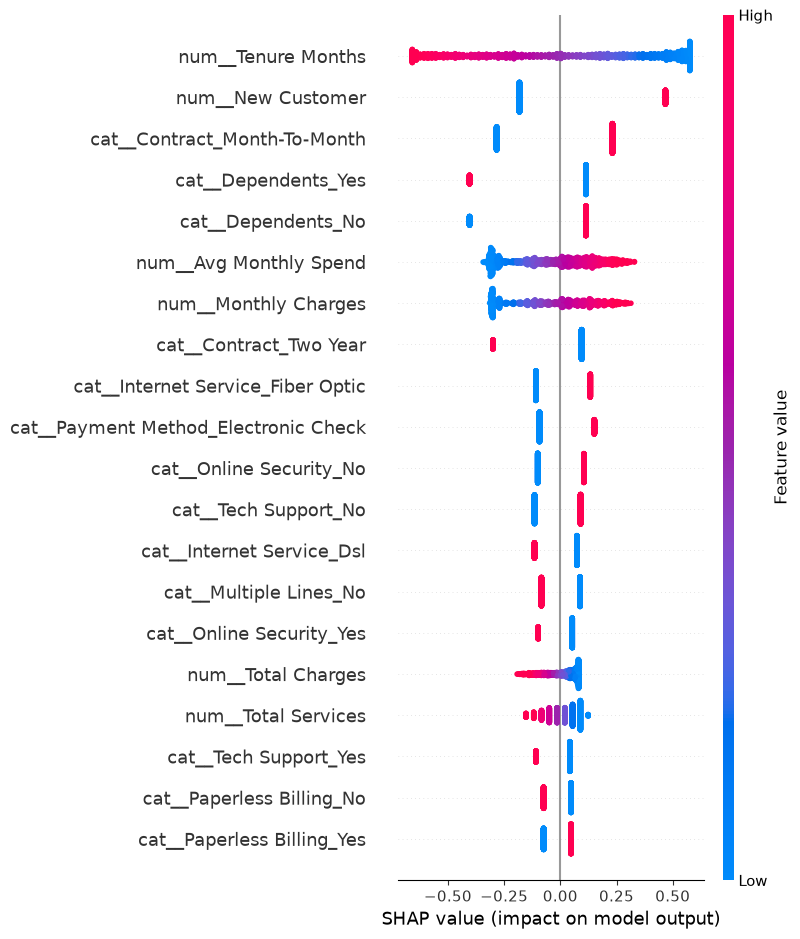

In [104]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

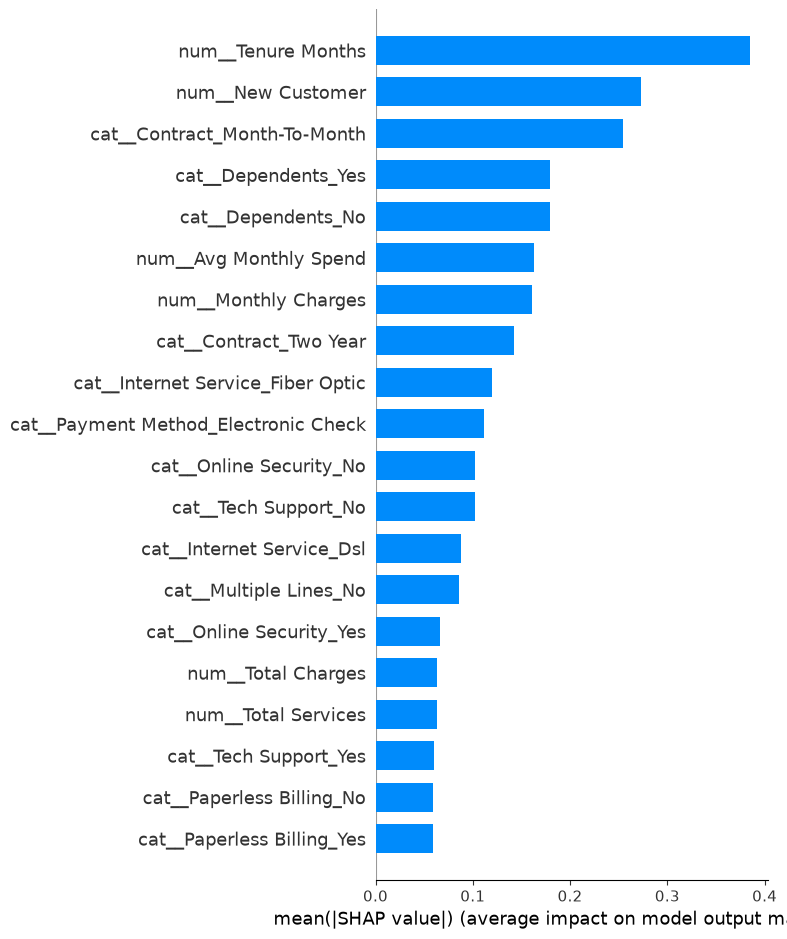

In [105]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type='bar'
)

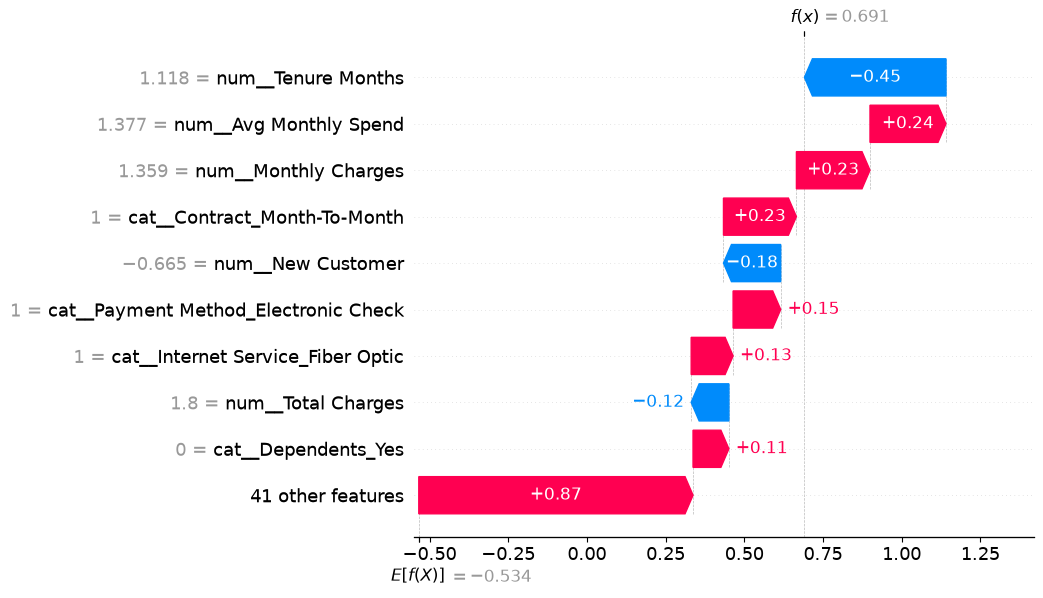

In [106]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[5],
        base_values=explainer.expected_value,
        data=X_test_processed[5],
        feature_names=feature_names
    )
)

In [107]:
feature_name_mapping = {
    # Numerical features
    'num__Tenure Months': 'Customer Tenure',
    'num__Monthly Charges': 'Monthly Charges',
    'num__Total Charges': 'Total Charges',
    'num__CLTV': 'Customer Lifetime Value',
    'num__Total Services': 'Number of Services',
    'num__New Customer': 'New Customer',
    'num__Avg Monthly Spend': 'Average Monthly Spend',

    # Demographics
    'cat__Gender_Female': 'Female',
    'cat__Gender_Male': 'Male',
    'cat__Senior Citizen_No': 'Not a Senior Citizen',
    'cat__Senior Citizen_Yes': 'Senior Citizen',
    'cat__Partner_No': 'No Partner',
    'cat__Partner_Yes': 'Has Partner',
    'cat__Dependents_No': 'No Dependents',
    'cat__Dependents_Yes': 'Has Dependents',

    # Phone Services
    'cat__Phone Service_No': 'No Phone Service',
    'cat__Phone Service_Yes': 'Phone Service',

    # Multiple Lines
    'cat__Multiple Lines_No': 'No Multiple Lines',
    'cat__Multiple Lines_No Phone Service': 'No Phone Service',
    'cat__Multiple Lines_Yes': 'Multiple Lines',

    # Internet Service
    'cat__Internet Service_Dsl': 'DSL Internet',
    'cat__Internet Service_Fiber Optic': 'Fiber Optic Internet',
    'cat__Internet Service_No': 'No Internet Service',

    # Online Security
    'cat__Online Security_No': 'No Online Security',
    'cat__Online Security_No Internet Service': 'No Internet Service',
    'cat__Online Security_Yes': 'Online Security',

    # Online Backup
    'cat__Online Backup_No': 'No Online Backup',
    'cat__Online Backup_No Internet Service': 'No Internet Service',
    'cat__Online Backup_Yes': 'Online Backup',

    # Device Protection
    'cat__Device Protection_No': 'No Device Protection',
    'cat__Device Protection_No Internet Service': 'No Internet Service',
    'cat__Device Protection_Yes': 'Device Protection',

    # Tech Support
    'cat__Tech Support_No': 'No Tech Support',
    'cat__Tech Support_No Internet Service': 'No Internet Service',
    'cat__Tech Support_Yes': 'Tech Support',

    # Streaming TV
    'cat__Streaming TV_No': 'No Streaming TV',
    'cat__Streaming TV_No Internet Service': 'No Internet Service',
    'cat__Streaming TV_Yes': 'Streaming TV',

    # Streaming Movies
    'cat__Streaming Movies_No': 'No Streaming Movies',
    'cat__Streaming Movies_No Internet Service': 'No Internet Service',
    'cat__Streaming Movies_Yes': 'Streaming Movies',

    # Contract
    'cat__Contract_Month-To-Month': 'Month-to-Month Contract',
    'cat__Contract_One Year': 'One-Year Contract',
    'cat__Contract_Two Year': 'Two-Year Contract',

    # Billing
    'cat__Paperless Billing_No': 'No Paperless Billing',
    'cat__Paperless Billing_Yes': 'Paperless Billing',

    # Payment Method
    'cat__Payment Method_Bank Transfer (Automatic)': 'Automatic Bank Transfer',
    'cat__Payment Method_Credit Card (Automatic)': 'Automatic Credit Card',
    'cat__Payment Method_Electronic Check': 'Electronic Check',
    'cat__Payment Method_Mailed Check': 'Mailed Check'
}

In [108]:
def generate_recommendations(
    churn_probability,
    risk_factors
):
    
    recommendations = []

    # High churn risk
    if churn_probability >= 0.7:
        recommendations.append(
            "Prioritize this customer for immediate retention outreach."
        )

    # Medium churn risk
    elif churn_probability >= 0.4:
        recommendations.append(
            "Monitor this customer closely and consider a targeted retention offer."
        )

    # Low churn risk
    else:
        recommendations.append(
            "No immediate retention intervention is required. Continue regular engagement."
        )

    # Check individual risk factors
    for _, row in risk_factors.iterrows():

        feature = row['Feature']

        if feature == 'Month-to-Month Contract':
            recommendations.append(
                "Offer an incentive to upgrade to a one-year or two-year contract."
            )

        elif feature == 'Monthly Charges':
            recommendations.append(
                "Review the customer's monthly charges and consider a personalized discount or value-added offer."
            )

        elif feature == 'Average Monthly Spend':
            recommendations.append(
                "Evaluate whether the customer's spending is perceived as high relative to the services received and consider a value-based offer."
            )

        elif feature == 'No Online Security':
            recommendations.append(
                "Offer an online security package or bundle to increase perceived service value."
            )

        elif feature == 'No Tech Support':
            recommendations.append(
                "Offer a technical support package or complimentary support period."
            )

        elif feature == 'Fiber Optic Internet':
            recommendations.append(
                "Review the customer's fiber-optic service experience, pricing, and satisfaction."
            )

        elif feature == 'Electronic Check':
            recommendations.append(
                "Encourage the customer to switch to an automatic payment method and offer a small billing incentive if appropriate."
            )

        elif feature == 'No Dependents':
            recommendations.append(
                "Consider personalized engagement offers that emphasize flexibility and individual customer value."
            )

        elif feature == 'Streaming TV':
            recommendations.append(
                "Review streaming service usage and consider bundling entertainment services with the customer's plan."
            )

        elif feature == 'Streaming Movies':
            recommendations.append(
                "Consider offering a bundled entertainment package to increase perceived value."
            )

        elif feature == 'New Customer':
            recommendations.append(
                "Strengthen early-stage customer engagement with onboarding support and proactive follow-up."
            )

    return recommendations

In [109]:
def analyze_customer(customer_index):

    # -----------------------------------
    # 1. Get customer data
    # -----------------------------------
    customer_data = X_test_processed[customer_index]

    # Reshape for model prediction
    customer_data_2d = customer_data.reshape(1, -1)


    # -----------------------------------
    # 2. Predict churn
    # -----------------------------------
    churn_probability = best_log_model.predict_proba(
        customer_data_2d
    )[0, 1]

    prediction = best_log_model.predict(
        customer_data_2d
    )[0]


    # -----------------------------------
    # 3. Determine risk level
    # -----------------------------------
    if churn_probability >= 0.7:
        risk_level = 'HIGH'

    elif churn_probability >= 0.4:
        risk_level = 'MEDIUM'

    else:
        risk_level = 'LOW'


    # -----------------------------------
    # 4. Get SHAP values
    # -----------------------------------
    customer_shap = shap_values[customer_index]


    # -----------------------------------
    # 5. Create explanation DataFrame
    # -----------------------------------
    explanation = pd.DataFrame({
        'Feature': feature_names,
        'SHAP Value': customer_shap,
        'Feature Value': customer_data
    })


    # -----------------------------------
    # 6. Keep only active features
    # -----------------------------------
    explanation = explanation[
        explanation['Feature Value'] != 0
    ].copy()


    # -----------------------------------
    # 7. Convert feature names
    # -----------------------------------
    explanation['Feature'] = explanation['Feature'].map(
        feature_name_mapping
    ).fillna(explanation['Feature'])


    # -----------------------------------
    # 8. Get top churn risk factors
    # -----------------------------------
    risk_factors = (
        explanation[
            explanation['SHAP Value'] > 0
        ]
        .sort_values(
            by='SHAP Value',
            ascending=False
        )
        .head(5)
    )


    # -----------------------------------
    # 9. Get top protective factors
    # -----------------------------------
    protective_factors = (
        explanation[
            explanation['SHAP Value'] < 0
        ]
        .sort_values(
            by='SHAP Value'
        )
        .head(5)
    )


    # -----------------------------------
    # 10. Generate recommendations
    # -----------------------------------

    recommendations = []


    # HIGH RISK
    if risk_level == 'HIGH':

        recommendations.append(
            "Prioritize this customer for immediate retention outreach."
        )

        recommendations.append(
            "Consider offering a personalized retention incentive."
        )


    # MEDIUM RISK
    elif risk_level == 'MEDIUM':

        recommendations.append(
            "Monitor this customer closely for changes in engagement."
        )

        recommendations.append(
            "Consider a targeted retention offer based on the customer's risk factors."
        )


    # LOW RISK
    else:

        recommendations.append(
            "No immediate retention intervention is required."
        )

        recommendations.append(
            "Continue regular customer engagement and monitor future behavior."
        )


    # -----------------------------------
    # 11. Feature-specific recommendations
    # -----------------------------------

    for _, row in risk_factors.iterrows():

        feature = row['Feature']


        if feature == 'Month-to-Month Contract':

            recommendations.append(
                "Consider offering an incentive to upgrade to a longer-term contract."
            )


        elif feature == 'Monthly Charges':

            recommendations.append(
                "Review the customer's monthly charges and consider a personalized value-based offer."
            )


        elif feature == 'Average Monthly Spend':

            recommendations.append(
                "Evaluate whether the customer's spending is high relative to the services received and consider improving perceived value."
            )


        elif feature == 'No Online Security':

            recommendations.append(
                "Consider offering an online security package or bundle."
            )


        elif feature == 'No Tech Support':

            recommendations.append(
                "Consider offering a technical support package or complimentary support period."
            )


        elif feature == 'Fiber Optic Internet':

            recommendations.append(
                "Review the customer's fiber-optic service experience, pricing, and satisfaction."
            )


        elif feature == 'Electronic Check':

            recommendations.append(
                "Consider encouraging the customer to switch to an automatic payment method."
            )


        elif feature == 'Streaming TV' or 'Streaming Movies':

            recommendations.append(
                "Consider offering a bundled entertainment package based on the customer's streaming usage."
            )


        elif feature == 'New Customer':

            recommendations.append(
                "Strengthen early-stage engagement through onboarding support and proactive follow-ups."
            )


    # -----------------------------------
    # 12. Remove duplicate recommendations
    # -----------------------------------

    recommendations = list(
        dict.fromkeys(recommendations)
    )


    # -----------------------------------
    # 13. Display results
    # -----------------------------------

    print("===================================")
    print("       CUSTOMER CHURN ANALYSIS")
    print("===================================")

    print(
        f"Churn Probability: "
        f"{churn_probability:.2%}"
    )

    print(
        f"Prediction: "
        f"{'Churn' if prediction == 1 else 'No Churn'}"
    )

    print(
        f"Risk Level: {risk_level}"
    )


    print("\n🔴 Top Churn Risk Factors")

    for _, row in risk_factors.iterrows():

        print(
            f"- {row['Feature']} "
            f"(SHAP: {row['SHAP Value']:.3f})"
        )


    print("\n🟢 Top Protective Factors")

    for _, row in protective_factors.iterrows():

        print(
            f"- {row['Feature']} "
            f"(SHAP: {row['SHAP Value']:.3f})"
        )


    print("\n💡 Recommended Actions")

    for i, recommendation in enumerate(
        recommendations,
        start=1
    ):

        print(
            f"{i}. {recommendation}"
        )


    # -----------------------------------
    # 14. Return structured results
    # -----------------------------------

    return {
        'churn_probability': churn_probability,
        'prediction': prediction,
        'risk_level': risk_level,
        'risk_factors': risk_factors,
        'protective_factors': protective_factors,
        'recommendations': recommendations
    }

In [110]:
def generate_ai_summary(result):

    # Get prediction details
    churn_probability = result['churn_probability']
    prediction = result['prediction']
    risk_level = result['risk_level']

    # Get risk factors
    risk_factors = [
        row['Feature']
        for _, row in result['risk_factors'].iterrows()
    ]

    # Get protective factors
    protective_factors = [
        row['Feature']
        for _, row in result['protective_factors'].iterrows()
    ]

    # Get recommendations
    recommendations = result['recommendations']


    # Create prompt
    prompt = f"""
You are a professional customer retention analyst.

Analyze the following customer churn prediction.

Churn Probability:
{churn_probability:.2%}

Prediction:
{'Churn' if prediction == 1 else 'No Churn'}

Risk Level:
{risk_level}

Top Churn Risk Factors:
{risk_factors}

Top Protective Factors:
{protective_factors}

Recommended Business Actions:
{recommendations}

Write a concise and professional customer risk summary.

Your response must:

1. Clearly state the customer's churn probability and risk level.
2. Explain the main factors contributing to the predicted churn risk.
3. Explain the main factors reducing the predicted churn risk.
4. Summarize the recommended business actions.
5. Do not invent any customer information.
6. Do not claim that a factor directly causes churn.
7. Use phrases such as "contributes to predicted risk" or
   "is associated with higher predicted churn risk."
8. Keep the response between 100 and 150 words.
"""


    # Send prompt to Gemini
    response = client.models.generate_content(
        model="gemini-3.1-flash-lite",
        contents=prompt
    )

    return response.text

In [111]:
result = analyze_customer(0)
ai_summary = generate_ai_summary(result)

# Step 3: Display AI summary
print("\n🤖 AI Business Summary")
print("----------------------")
print(ai_summary)

       CUSTOMER CHURN ANALYSIS
Churn Probability: 14.63%
Prediction: No Churn
Risk Level: LOW

🔴 Top Churn Risk Factors
- No Dependents (SHAP: 0.114)
- No Online Security (SHAP: 0.105)
- Streaming TV (SHAP: 0.062)
- Streaming Movies (SHAP: 0.060)
- Average Monthly Spend (SHAP: 0.054)

🟢 Top Protective Factors
- Customer Tenure (SHAP: -0.432)
- Two-Year Contract (SHAP: -0.300)
- New Customer (SHAP: -0.182)
- DSL Internet (SHAP: -0.115)
- Tech Support (SHAP: -0.109)

💡 Recommended Actions
1. No immediate retention intervention is required.
2. Continue regular customer engagement and monitor future behavior.
3. Consider offering a bundled entertainment package based on the customer's streaming usage.
4. Consider offering an online security package or bundle.
5. Evaluate whether the customer's spending is high relative to the services received and consider improving perceived value.

🤖 AI Business Summary
----------------------
This customer presents a low churn risk, with a calculated chu